In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.constants as cst
import matplotlib.ticker as ticker

In [2]:
def G(B,theta, ptt, A):
    pt  = ptt
    pr  = 1-pt
    prr = 1-ptt
    rrs = np.sqrt(prr)
    rs  = np.sqrt(pr)
    flux_q = cst.h/cst.e
    flux = B*A*np.cos(theta)
    p_AB = 2*np.pi*flux/flux_q
    return pt**2 * np.real(1/(1 - rrs*rs*np.exp(1j*2*p_AB) - rrs*rs*np.exp(-1j*2*p_AB) + np.power(rrs*rs,2)))

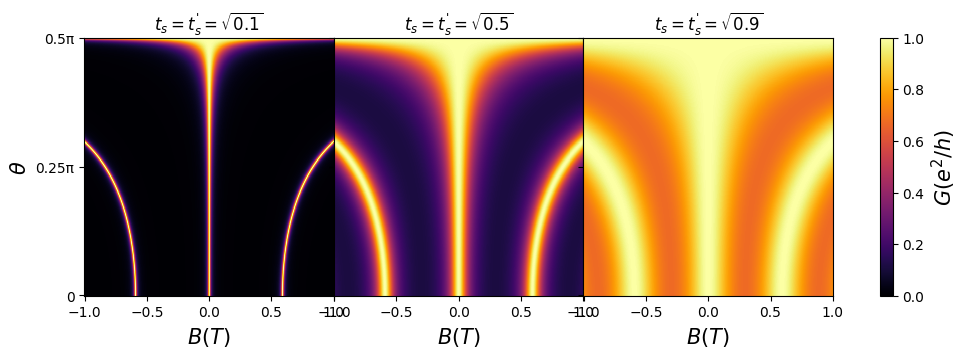

In [3]:
B = np.linspace(-1,1,500)
theta = np.linspace(0,np.pi/2,500)
xx, yy = np.meshgrid(B, theta)


fig, axs = plt.subplots(1,3, figsize=(12,3), sharey=True)
plt.subplots_adjust(wspace=0,hspace=0,top=0.98,right=0.98,bottom=0.12,left=0.2)
axs[0].pcolormesh(xx,yy,G(xx,yy,0.1,(50*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)
axs[1].pcolormesh(xx,yy,G(xx,yy,0.5,(50*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)
c = axs[2].pcolormesh(xx,yy,G(xx,yy,0.9,(50*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)

# Set y-axis ticks to multiples of pi
for ax in axs:
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=np.pi / 4))  # Set the tick intervals to pi/4
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/np.pi:.2g}π' if val != 0 else '0'))



axs[0].set_xlabel(r'$B(T)$', fontsize = 15)
axs[1].set_xlabel(r'$B(T)$', fontsize = 15)
axs[2].set_xlabel(r'$B(T)$', fontsize = 15)
axs[0].set_title(r"$t_s=t_s^'=\sqrt{0.1}$")
axs[1].set_title(r"$t_s=t_s^'=\sqrt{0.5}$")
axs[2].set_title(r"$t_s=t_s^'=\sqrt{0.9}$")

axs[0].set_ylabel(r'$\theta$', fontsize = 15)
cbar = fig.colorbar(c, ax=axs) 
cbar.set_label(r"$G (e^2/h)$", fontsize = 15)
plt.savefig('t.png',dpi=300,bbox_inches='tight')

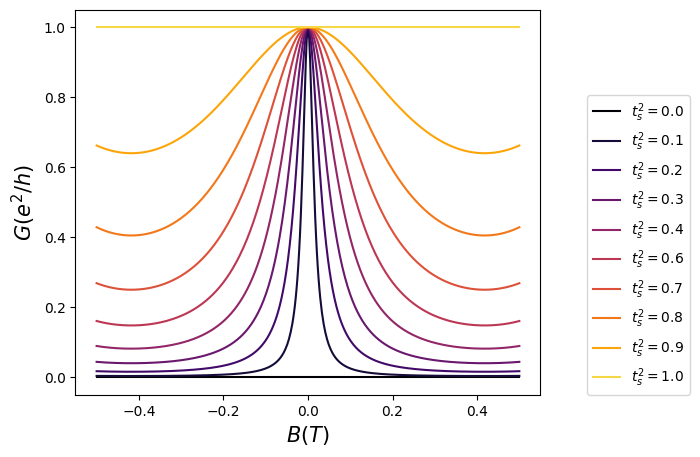

In [4]:
Barr = np.linspace(-0.5,0.5,500)
ptarr = np.linspace(0,1,10)      # transparency
theta = np.pi/4
fig, axs = plt.subplots(figsize=(6,5))
colors = plt.get_cmap('inferno')(np.linspace(0,0.9,10))
for i,pt in enumerate(ptarr):
    axs.plot(Barr, G(Barr,theta,pt,(50*50*1.4)*1e-18), color=colors[i], label=r"$t_s^2 = {:.1f} $".format(pt)) 
plt.legend(loc=(1.1,0.0))
axs.set_xlabel(r'$B(T)$', fontsize = 15)
axs.set_ylabel(r'$G(e^2/h)$', fontsize = 15)
plt.savefig('varTran.png', dpi = 300, bbox_inches = 'tight')

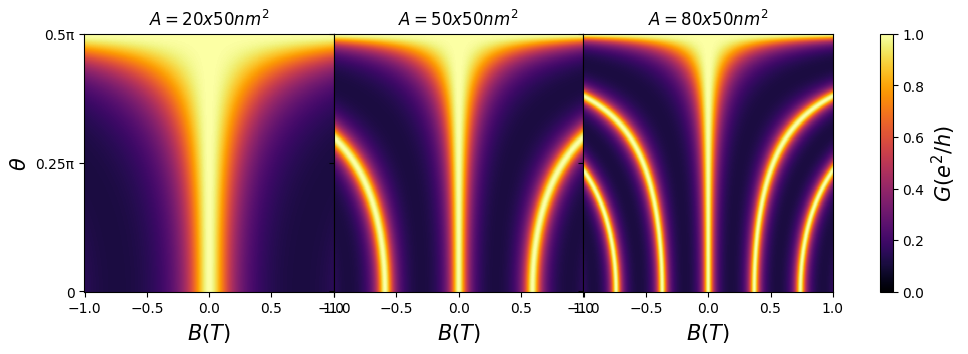

In [5]:
B = np.linspace(-1,1,500)
theta = np.linspace(0,np.pi/2,500)
xx, yy = np.meshgrid(B, theta)



fig, axs = plt.subplots(1,3, figsize=(12,3), sharey=True)
plt.subplots_adjust(wspace=0,hspace=0,top=0.98,right=0.98,bottom=0.12,left=0.2)
axs[0].pcolormesh(xx,yy,G(xx,yy,0.5,(20*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)
axs[1].pcolormesh(xx,yy,G(xx,yy,0.5,(50*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)
c = axs[2].pcolormesh(xx,yy,G(xx,yy,0.5,(80*50*1.4)*1e-18),cmap="inferno", vmin=0, vmax=1)

# Set y-axis ticks to multiples of pi
for ax in axs:
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=np.pi / 4))  # Set the tick intervals to pi/4
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/np.pi:.2g}π' if val != 0 else '0'))

axs[0].set_xlabel(r'$B(T)$', fontsize = 15)
axs[1].set_xlabel(r'$B(T)$', fontsize = 15)
axs[2].set_xlabel(r'$B(T)$', fontsize = 15)
axs[0].set_title(r"$A=20x50nm^2$")
axs[1].set_title(r"$A=50x50nm^2$")
axs[2].set_title(r"$A=80x50nm^2$")

axs[0].set_ylabel(r'$\theta$', fontsize = 15)
cbar = fig.colorbar(c, ax=axs) 
cbar.set_label(r"$G (e^2/h)$", fontsize = 15)
plt.savefig('a.png',dpi=300,bbox_inches='tight')

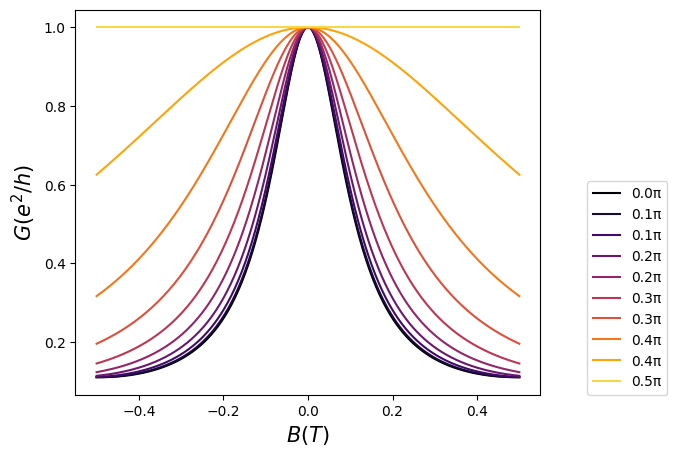

In [12]:
Barr = np.linspace(-0.5,0.5,500)
tarr = np.linspace(0,np.pi/2,10)
fig, axs = plt.subplots(figsize=(6,5))
colors = plt.get_cmap('inferno')(np.linspace(0,0.9,10))
for i,theta in enumerate(tarr):
    axs.plot(Barr, G(Barr,theta,0.5,(50*30*1.4)*1e-18), color=colors[i], label=f'{theta/np.pi:.1f}π') 
plt.legend(loc=(1.1,0.0))
axs.set_xlabel(r'$B(T)$', fontsize = 15)
axs.set_ylabel(r'$G(e^2/h)$', fontsize = 15)
plt.savefig('varTheta.png', dpi = 300, bbox_inches = 'tight')

Text(0, 0.5, '$G(e^2/h)$')

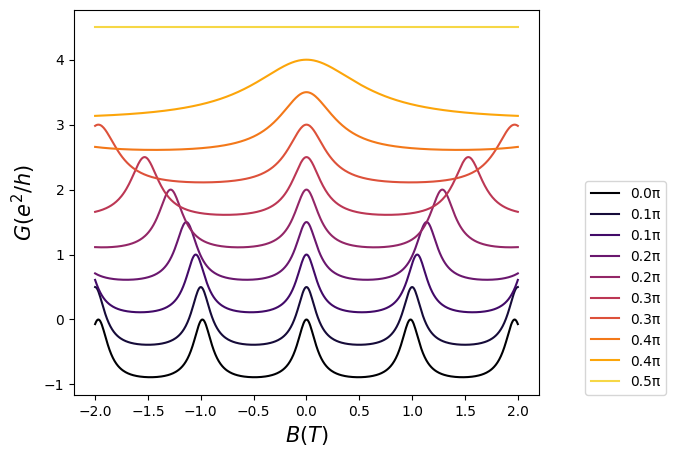

In [80]:
offset = 0.5

Barr = np.linspace(-2,2,500)
tarr = np.linspace(0,np.pi/2,10)
fig, axs = plt.subplots(figsize=(6,5))
colors = plt.get_cmap('inferno')(np.linspace(0,0.9,10))
for i,theta in enumerate(tarr):
    axs.plot(Barr, G(Barr,theta,0.5,(50*30*1.4)*1e-18) - np.max(G(Barr,theta,0.5,(50*30*1.4)*1e-18))+offset*i, color=colors[i], label=f'{theta/np.pi:.1f}π') 
plt.legend(loc=(1.1,0.0))
axs.set_xlabel(r'$B(T)$', fontsize = 15)
axs.set_ylabel(r'$G(e^2/h)$', fontsize = 15)

Text(0, 0.5, '$R(h/e^2)$')

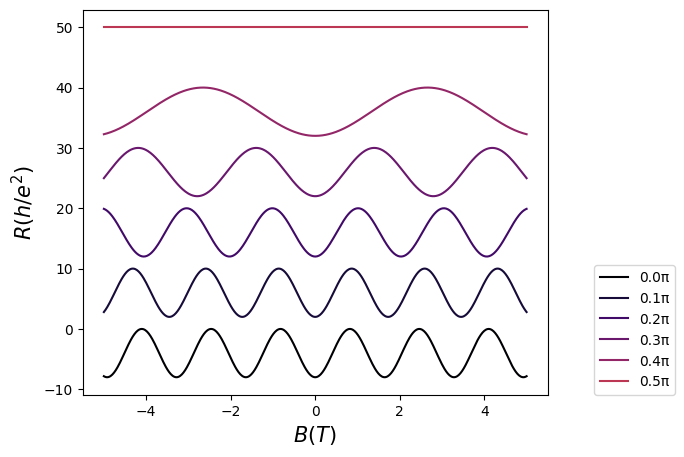

In [78]:
offset = 10

Barr = np.linspace(-5,5,500)
tarr = np.linspace(0,np.pi/2,6)
fig, axs = plt.subplots(figsize=(6,5))
colors = plt.get_cmap('inferno')(np.linspace(0,0.9,10))
for i,theta in enumerate(tarr):
    axs.plot(Barr, 1/G(Barr,theta,0.5,(30*30*1.4)*1e-18) - np.max(1/G(Barr,theta,0.5,(30*30*1.4)*1e-18))+offset*i, color=colors[i], label=f'{theta/np.pi:.1f}π') 
plt.legend(loc=(1.1,0.0))
axs.set_xlabel(r'$B(T)$', fontsize = 15)
axs.set_ylabel(r'$R(h/e^2)$', fontsize = 15)